<a href="https://colab.research.google.com/github/CarlosJB95/PathIA-MSI-colon/blob/main/notebooks/Notebook_05_WSI_OpenSlide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

In [2]:
# 1) Binarios + wrapper (si ya los instalaste, no pasa nada por repetir)
!apt-get -qq install -y openslide-tools
!pip install -q openslide-python

# 2) Descarga la WSI de muestra (Aperio CMU-1, licencia CC0)
!wget -q -O CMU-1.svs https://openslide.cs.cmu.edu/download/openslide-testdata/Aperio/CMU-1.svs

# 3) Ábrela con la RUTA REAL (nota: "CMU-1.svs", no ruta_wsi)
import openslide
slide = openslide.OpenSlide("CMU-1.svs")

print("Niveles:        ", slide.level_count)
print("Dims nivel 0:   ", slide.dimensions)          # (ANCHO, ALTO) ⚠️
print("Dims por nivel: ", slide.level_dimensions)
print("Downsamples:    ", slide.level_downsamples)
print("MPP-x:", slide.properties.get(openslide.PROPERTY_NAME_MPP_X))
print("MPP-y:", slide.properties.get(openslide.PROPERTY_NAME_MPP_Y))

Selecting previously unselected package libopenslide0.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-7build2_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-7build2) ...
Selecting previously unselected package openslide-tools.
Preparing to unpack .../openslide-tools_3.4.1+dfsg-7build2_amd64.deb ...
Unpacking openslide-tools (3.4.1+dfsg-7build2) ...
Setting up libopenslide0 (3.4.1+dfsg-7build2) ...
Setting up openslide-tools (3.4.1+dfsg-7build2) ...
Processing triggers for man-db (2.12.0-4build2) ...
Processing triggers for libc-bin (2.39-0ubuntu8.9) ...
/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_de

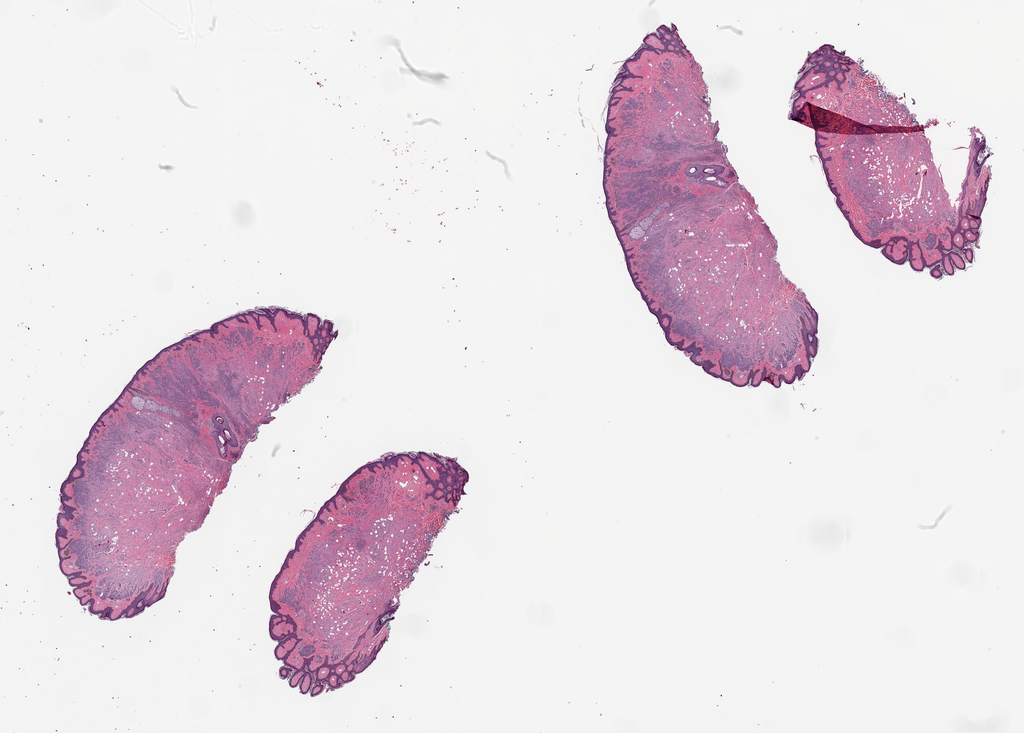

shape: (512, 512, 4) | dtype: uint8


In [3]:
import numpy as np

# thumbnail: la laminilla completa "a bajo aumento" para ubicarnos
thumb = slide.get_thumbnail((1024, 1024))
display(thumb)

# read_region: (x, y) SIEMPRE en coords de nivel 0, el nivel a leer, y (ancho, alto) del campo
region = slide.read_region((15000, 15000), 0, (512, 512))
arr = np.array(region)
print("shape:", arr.shape, "| dtype:", arr.dtype)

In [4]:
arr_rgb = arr[:, :, :3]        # nos quedamos con R, G, B (los 3 primeros canales)
# o, más limpio, convirtiendo antes de pasar a array:
# arr = np.array(region.convert("RGB"))

In [5]:
import numpy as np

tiles = []                       # aquí se acumula el manifest (lista de filas)
paso = 512
for y in range(0, 1024, paso):
    for x in range(0, 1024, paso):
        region = slide.read_region((x, y), 0, (paso, paso))
        arr = np.array(region.convert("RGB"))     # descartamos alfa de una vez
        tiles.append({
            "slide_id": "CMU-1",
            "x": x, "y": y, "nivel": 0,
            "w": paso, "h": paso,
            "MPP": 0.499, "fuente": "openslide-testdata", "semilla": 42,
        })

print("Tiles registrados:", len(tiles))
for fila in tiles:
    print(fila)

Tiles registrados: 4
{'slide_id': 'CMU-1', 'x': 0, 'y': 0, 'nivel': 0, 'w': 512, 'h': 512, 'MPP': 0.499, 'fuente': 'openslide-testdata', 'semilla': 42}
{'slide_id': 'CMU-1', 'x': 512, 'y': 0, 'nivel': 0, 'w': 512, 'h': 512, 'MPP': 0.499, 'fuente': 'openslide-testdata', 'semilla': 42}
{'slide_id': 'CMU-1', 'x': 0, 'y': 512, 'nivel': 0, 'w': 512, 'h': 512, 'MPP': 0.499, 'fuente': 'openslide-testdata', 'semilla': 42}
{'slide_id': 'CMU-1', 'x': 512, 'y': 512, 'nivel': 0, 'w': 512, 'h': 512, 'MPP': 0.499, 'fuente': 'openslide-testdata', 'semilla': 42}


Umbral de Otsu: 0.729
% marcado como tejido: 18.5


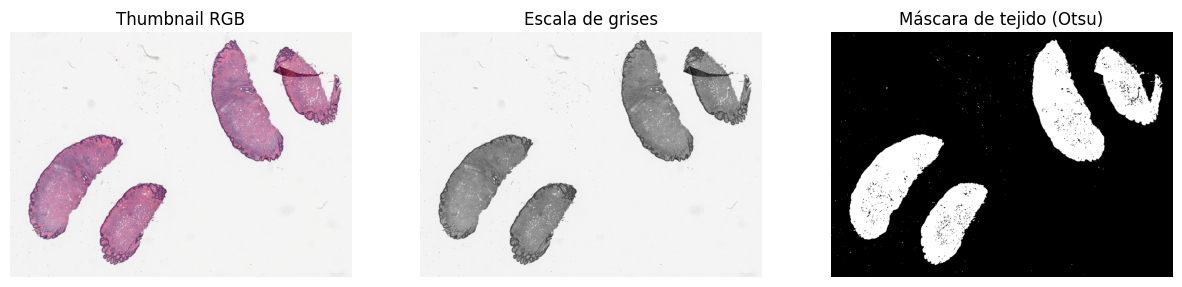

In [6]:
import numpy as np
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

thumb_rgb = np.array(slide.get_thumbnail((1024, 1024)).convert("RGB"))
gray = rgb2gray(thumb_rgb)              # brillo por píxel, 0.0–1.0

umbral = threshold_otsu(gray)
mascara = gray < umbral                 # tejido = MÁS OSCURO que el umbral

print("Umbral de Otsu:", round(float(umbral), 3))
print("% marcado como tejido:", round(100 * mascara.mean(), 1))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(thumb_rgb);        ax[0].set_title("Thumbnail RGB");   ax[0].axis("off")
ax[1].imshow(gray, cmap="gray");ax[1].set_title("Escala de grises");ax[1].axis("off")
ax[2].imshow(mascara, cmap="gray"); ax[2].set_title("Máscara de tejido (Otsu)"); ax[2].axis("off")
plt.show()

In [7]:
for t in tiles:
    region = slide.read_region((t["x"], t["y"]), t["nivel"], (t["w"], t["h"]))
    g = rgb2gray(np.array(region.convert("RGB")))
    pct = float((g < umbral).mean())      # umbral GLOBAL = 0.729, de la mañana
    t["pct_tejido"] = round(pct, 3)
    t["conservar"]  = pct >= 0.5          # umbral por tile = decisión de diseño
    print(f'({t["x"]:>5},{t["y"]:>5}) → %tejido: {t["pct_tejido"]:.3f} | conservar: {t["conservar"]}')

(    0,    0) → %tejido: 0.000 | conservar: False
(  512,    0) → %tejido: 0.000 | conservar: False
(    0,  512) → %tejido: 0.000 | conservar: False
(  512,  512) → %tejido: 0.000 | conservar: False


In [8]:
git add 05_wsi_openslide.ipynb
git commit -m "Día 21 — Mes 2: OpenSlide + pirámide/MPP + read_region + Otsu tejido/fondo + manifest embrión"

SyntaxError: invalid decimal literal (2354467295.py, line 1)